# 🎓 **Maestría en Inteligencia Artificial Aplicada**

## 🖥️ **Curso: Cómputo en la Nube (Gpo 10)**

### 🏛️ Tecnológico de Monterrey

#### 👨‍🏫 **Profesor Titular:** Gilberto Echeverría Furió
#### 👩‍🏫 **Profesor Asistente:** Yetnalezi Quintas Ruiz

### 📊 **Tarea 7 | Usar APIs en la nube**

#### 📅 **15 de Marzo, 2026**

#### **Estudiante:**
* 🧑‍💻 Oscar Enrique García García (A01016093)

# 1. Importación de librerías

En esa sección se importan las librerías que usaremos dentro del código, de forma global, para el manejo de variables de ambiente, solicitudes a la API y de datos recuperados.

In [5]:
import json, os, requests
from dotenv import load_dotenv

In [59]:
load_dotenv() #Cargamos nuestro archivo local de variables

True

# 2. Definición de API Key y Endpoint

En esta sección definimos nuestra API Key que utilizaremoos para conectarnos con el servicio en Azure, para detección de rostros, así como el endpoint de la API a utilizar: face/v1.0/detect

In [ ]:
#Definimos nuestra variable con la clave generada en el portal de Azure
subscription_key = os.getenv("SUBSCRIPTION_KEY")

#URL de la aplicación que queremos correr
face_api_url = "https://facerecognitionmnaog.cognitiveservices.azure.com" + '/face/v1.0/detect'

# 3. Ejemplo de solicitud y respuesta de la API de detección de rostros

En esta sección haremos una demostración de una solicitud hacia la API de detección, a partir de una imagen pública y mostraremos también los resultados que se arrojan al enviar la solicitud.

In [25]:
#URL de una imagen a utilizar
image_url = 'https://raw.githubusercontent.com/gilecheverria/MNA_data/main/Images/amusement_park.png'

#Configuración de la clave a utilizar

headers = {'Ocp-Apim-Subscription-Key': subscription_key}

In [26]:
#Parámetros para la solicitud del servicio

params = {'returnFaceId': 'false',
          'returnFaceLandmarks': 'true'}

In [28]:
#Llamada al servicio
response = requests.post(face_api_url, params=params, headers=headers,json={"url": image_url})
#Almacenar el resultado en formato JSON
faces = response.json()
#Mostrar el resultado como texto
json.dumps(faces)

'[{"faceRectangle": {"top": 352, "left": 467, "width": 50, "height": 50}, "faceLandmarks": {"pupilLeft": {"x": 479.8, "y": 366.1}, "pupilRight": {"x": 503.6, "y": 367.2}, "noseTip": {"x": 493.8, "y": 377.7}, "mouthLeft": {"x": 479.6, "y": 388.1}, "mouthRight": {"x": 500.7, "y": 389.4}, "eyebrowLeftOuter": {"x": 470.8, "y": 361.6}, "eyebrowLeftInner": {"x": 489.6, "y": 361.4}, "eyeLeftOuter": {"x": 477.3, "y": 366.6}, "eyeLeftTop": {"x": 480.2, "y": 365.6}, "eyeLeftBottom": {"x": 480.2, "y": 367.2}, "eyeLeftInner": {"x": 483.0, "y": 366.6}, "eyebrowRightInner": {"x": 497.2, "y": 361.6}, "eyebrowRightOuter": {"x": 513.3, "y": 363.2}, "eyeRightInner": {"x": 500.1, "y": 367.2}, "eyeRightTop": {"x": 503.6, "y": 366.3}, "eyeRightBottom": {"x": 503.7, "y": 367.7}, "eyeRightOuter": {"x": 506.6, "y": 367.4}, "noseRootLeft": {"x": 488.6, "y": 367.0}, "noseRootRight": {"x": 496.0, "y": 367.1}, "noseLeftAlarTop": {"x": 487.1, "y": 374.2}, "noseRightAlarTop": {"x": 497.6, "y": 374.6}, "noseLeftAlar

# 4. Función reutilizable para impresión de puntos clave de detección de rostros

En esta sección se construye una función reutilizable que imprime los puntos claves, a partir de la respuesta (JSON) que regresa la solicitud hacia la API de detección de rostros. De esta forma, podemos ver qué rostros, además de otros puntos: ojos, labios, cejas, pupilas, etc. que nos devuelve la misma solicitud

In [57]:
def print_landmarks(image_url, data):
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image, ImageDraw
    from io import BytesIO
    from IPython.display import display

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Also show all rows (careful with large datasets!)
    pd.set_option('display.max_rows', None)

    # 1. Descargar la imagen para mostrarla
    response_img = requests.get(image_url)
    img = Image.open(BytesIO(response_img.content))

    draw = ImageDraw.Draw(img)

    for face in faces:
    # --- 1. Dibujar el Rectángulo (Tu código actual) ---
        rect = face['faceRectangle']
        left, top = rect['left'], rect['top']
        right, bottom = left + rect['width'], top + rect['height']
        draw.rectangle([left, top, right, bottom], outline='red', width=3)
    
        # --- 2. Dibujar los Landmarks (Puntos de referencia) ---
        landmarks = face['faceLandmarks']
        
        # El tamaño del radio para el punto (en píxeles)
        r = 2 
        
        for feature_name, coords in landmarks.items():
            x, y = coords['x'], coords['y']
            
            # Dibujamos un círculo pequeño (elipse)
            # La fórmula es: [x-r, y-r, x+r, y+r]
            draw.ellipse([x - r, y - r, x + r, y + r], fill='blue', outline='white')

    # Mostrar resultado
    plt.figure(figsize=(14, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Se detectaron {len(faces)} rostros")
    plt.show()

    df = pd.json_normalize(data)
    display(df)


# 5. El código en acción

En esta sección se utilizará la función previamente creada para mostrar los resultados obtenidos por la API de detección de rostros, mostrando qué rostros y atributos se detectaron dentro de una serie de imágenes.

## 5.1 Ejemplo con imagen de la guía

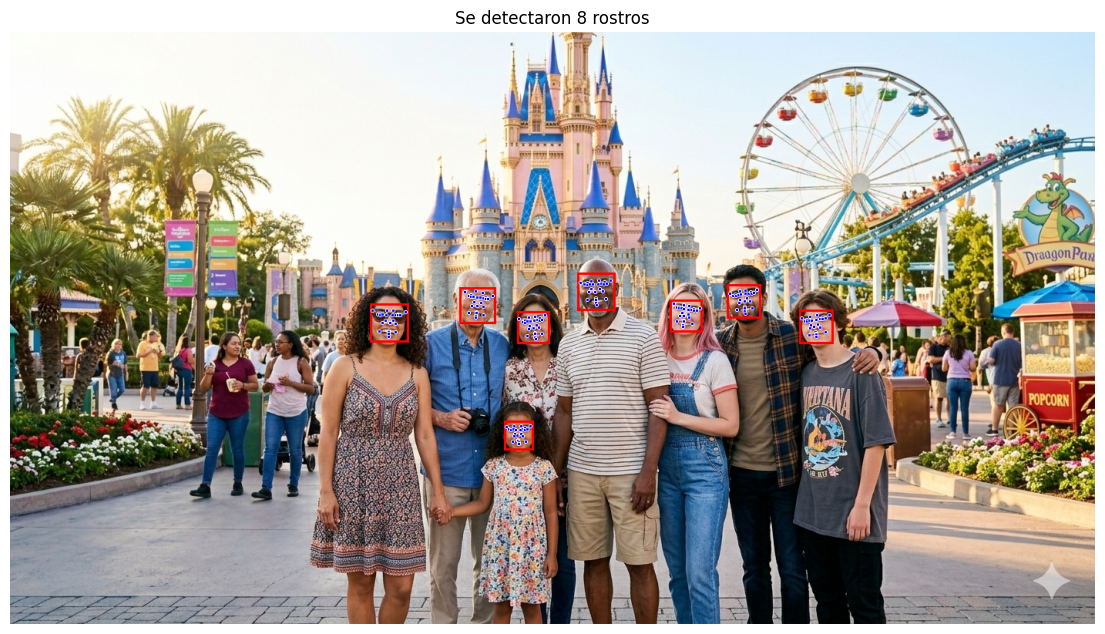

,faceRectangle.top,faceRectangle.left,faceRectangle.width,faceRectangle.height,faceLandmarks.pupilLeft.x,faceLandmarks.pupilLeft.y,faceLandmarks.pupilRight.x,faceLandmarks.pupilRight.y,faceLandmarks.noseTip.x,faceLandmarks.noseTip.y,faceLandmarks.mouthLeft.x,faceLandmarks.mouthLeft.y,faceLandmarks.mouthRight.x,faceLandmarks.mouthRight.y,faceLandmarks.eyebrowLeftOuter.x,faceLandmarks.eyebrowLeftOuter.y,faceLandmarks.eyebrowLeftInner.x,faceLandmarks.eyebrowLeftInner.y,faceLandmarks.eyeLeftOuter.x,faceLandmarks.eyeLeftOuter.y,faceLandmarks.eyeLeftTop.x,faceLandmarks.eyeLeftTop.y,faceLandmarks.eyeLeftBottom.x,faceLandmarks.eyeLeftBottom.y,faceLandmarks.eyeLeftInner.x,faceLandmarks.eyeLeftInner.y,faceLandmarks.eyebrowRightInner.x,faceLandmarks.eyebrowRightInner.y,faceLandmarks.eyebrowRightOuter.x,faceLandmarks.eyebrowRightOuter.y,faceLandmarks.eyeRightInner.x,faceLandmarks.eyeRightInner.y,faceLandmarks.eyeRightTop.x,faceLandmarks.eyeRightTop.y,faceLandmarks.eyeRightBottom.x,faceLandmarks.eyeRightBottom.y,faceLandmarks.eyeRightOuter.x,faceLandmarks.eyeRightOuter.y,faceLandmarks.noseRootLeft.x,faceLandmarks.noseRootLeft.y,faceLandmarks.noseRootRight.x,faceLandmarks.noseRootRight.y,faceLandmarks.noseLeftAlarTop.x,faceLandmarks.noseLeftAlarTop.y,faceLandmarks.noseRightAlarTop.x,faceLandmarks.noseRightAlarTop.y,faceLandmarks.noseLeftAlarOutTip.x,faceLandmarks.noseLeftAlarOutTip.y,faceLandmarks.noseRightAlarOutTip.x,faceLandmarks.noseRightAlarOutTip.y,faceLandmarks.upperLipTop.x,faceLandmarks.upperLipTop.y,faceLandmarks.upperLipBottom.x,faceLandmarks.upperLipBottom.y,faceLandmarks.underLipTop.x,faceLandmarks.underLipTop.y,faceLandmarks.underLipBottom.x,faceLandmarks.underLipBottom.y
0,352,467,50,50,479.8,366.1,503.6,367.2,493.8,377.7,479.6,388.1,500.7,389.4,470.8,361.6,489.6,361.4,477.3,366.6,480.2,365.6,480.2,367.2,483.0,366.6,497.2,361.6,513.3,363.2,500.1,367.2,503.6,366.3,503.7,367.7,506.6,367.4,488.6,367.0,496.0,367.1,487.1,374.2,497.6,374.6,483.8,377.9,500.6,378.6,491.3,387.0,491.3,389.2,491.1,391.8,491.0,395.3
1,312,736,49,49,749.2,326.6,771.3,326.0,759.4,337.7,749.7,347.8,773.5,346.8,740.6,325.1,754.6,323.0,745.8,327.7,749.0,325.6,749.3,328.5,752.5,327.2,764.8,322.3,779.7,322.9,767.5,326.6,771.2,324.6,770.9,327.7,774.6,326.6,756.5,327.2,763.2,327.0,754.9,333.5,765.3,333.4,751.6,337.5,769.1,336.6,760.2,345.2,760.5,347.3,760.8,351.6,761.1,354.9
2,331,583,47,47,598.6,342.4,617.8,345.6,606.6,355.2,595.2,364.5,614.4,367.7,590.9,337.6,604.1,336.2,595.3,342.6,598.8,341.6,598.6,343.5,601.6,343.6,613.5,338.1,626.1,342.4,614.3,345.6,617.4,344.9,617.2,346.7,620.4,346.7,606.0,344.3,610.5,344.9,602.8,350.9,611.3,351.6,599.6,355.0,614.0,356.5,605.1,363.2,605.1,364.7,604.4,368.5,604.2,370.7
3,360,1024,44,44,1035.1,374.5,1055.0,371.7,1043.7,382.7,1037.0,393.4,1058.6,389.8,1027.4,371.9,1038.0,369.2,1031.9,375.7,1034.1,373.7,1034.8,375.4,1037.4,374.2,1047.5,367.9,1063.2,367.1,1051.4,372.2,1054.8,370.8,1054.6,372.4,1058.0,371.7,1040.7,374.0,1046.5,373.4,1039.2,380.6,1048.7,379.6,1038.2,384.4,1051.4,383.0,1045.9,389.9,1046.1,391.3,1046.7,392.9,1046.9,395.4
4,327,930,44,44,942.2,341.0,961.7,338.1,953.3,349.2,943.0,360.2,963.5,358.0,934.1,339.5,947.7,336.4,938.5,342.0,941.7,340.0,942.2,342.6,945.5,341.0,954.2,335.1,969.0,334.0,958.8,339.4,961.6,337.7,962.1,339.8,965.2,338.4,948.6,340.5,954.5,339.9,947.7,347.1,956.8,345.9,946.4,351.0,960.5,349.1,953.5,356.1,953.6,358.3,953.7,362.1,954.0,365.3
5,362,658,42,42,668.7,375.5,687.2,372.7,679.5,384.4,671.9,394.2,690.6,391.5,660.5,372.6,673.5,370.9,665.2,376.6,668.4,374.6,668.5,377.1,671.6,375.7,681.9,369.2,694.5,367.6,684.3,373.8,687.1,371.6,687.5,374.2,690.7,373.0,675.9,375.7,680.4,374.9,674.8,381.7,683.4,380.7,673.2,385.3,686.2,383.7,681.3,390.1,681.5,391.5,681.8,396.0,682.3,398.5
6,347,856,42,42,868.9,357.4,887.9,360.6,874.9,368.6,865.2,375.2,885.1,378.1,861.0,352.8,874.4,354.9,865.0,357.4,868.5,356.6,868.2,358.7,871.4,358.7,881.6,355.8,895.9,358.6,884.2,360.7,887.7,359.7,887.6,361.9,891.2,361.5,874.8,359.8

In [58]:
print_landmarks(image_url, faces)

## 5.2 Ejemplos con imágenes propias

In [ ]:
image_url = 'https://raw.githubusercontent.com/gilecheverria/MNA_data/main/Images/amusement_park.png'

#Llamada al servicio
response = requests.post(face_api_url, params=params, headers=headers,json={"url": image_url})
#Almacenar el resultado en formato JSON
faces = response.json()
#Mostrar el resultado como texto
json.dumps(faces)